## What is Markdown?

Colab has two types of cells: text and code. Text cells are formatted using a simple markup language called Markdown.


To see the Markdown source, double-click a text cell, showing both the Markdown source and the rendered version. Above the Markdown source there is a toolbar to assist editing.

#Vanishing Gradient

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD,Adam
from tensorflow.keras.utils import to_categorical

In [6]:
X,y = make_moons(n_samples=500,noise=0.02,random_state=42)

y = to_categorical(y) # pne hot encoding for softmax

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)

(400, 2) (100, 2)
(400, 2) (100, 2)


In [7]:

def build_model(activation='sigmoid',hidden_layes=10,hidden_units=32,lr=0.01):
    model= Sequential()

    # Input + hidden layers
    for _ in range(hidden_layes):
        model.add(Dense(hidden_units,activation=activation,input_dim=2 if _ == 0 else hidden_units))

    #Output layer (binary classification)
    model.add(Dense(2,activation='softmax'))
    model.compile(optimizer=SGD(learning_rate=lr),loss = 'categorical_crossentropy',metrics=['accuracy'])

    return model

In [8]:

# train models with different activations
histories = {}
activations = ['sigmoid','tanh','relu']

for act in activations:
    print(f'training with activations :{act}')
    model = build_model(activation=act,hidden_layes=10,hidden_units=32,lr=0.01)
    history = model.fit(x_train,y_train,validation_data =(x_test,y_test),epochs=50,batch_size=32,verbose=1)
    histories[act] = history


training with activations :sigmoid


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4602 - loss: 0.8323 - val_accuracy: 0.5700 - val_loss: 0.6907
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4954 - loss: 0.7204 - val_accuracy: 0.5700 - val_loss: 0.6836
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4700 - loss: 0.7037 - val_accuracy: 0.5700 - val_loss: 0.6870
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4401 - loss: 0.6983 - val_accuracy: 0.5700 - val_loss: 0.6917
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5200 - loss: 0.6927 - val_accuracy: 0.4300 - val_loss: 0.6964
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5277 - loss: 0.6923 - val_accuracy: 0.4300 - val_loss: 0.6996
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5240 - loss: 0.6927 - val_accuracy: 0.4300 - val_loss: 0.6964
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4769 - loss: 0.6947 - val_accuracy: 0.4300 - val_lo

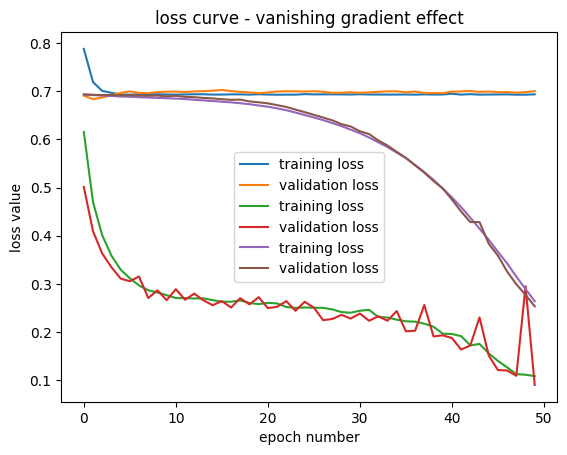

In [10]:
# plot loss curve

for act in activations:
    plt.plot(histories[act].history['loss'], label='training loss')
    plt.plot(histories[act].history['val_loss'], label='validation loss')

plt.title("loss curve - vanishing gradient effect")
plt.xlabel("epoch number")
plt.ylabel("loss value")
plt.legend()
plt.show()

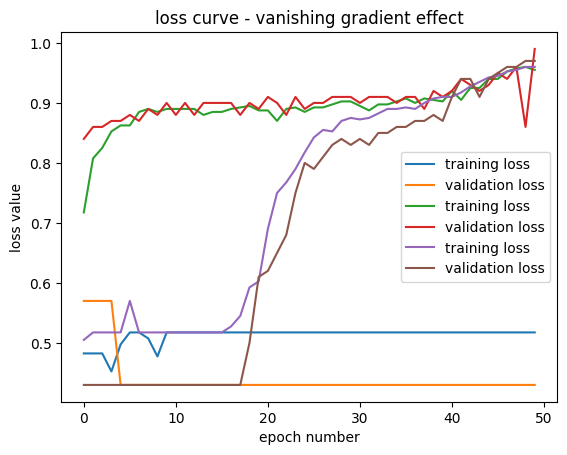

In [11]:
# plot loss curve

for act in activations:
    plt.plot(histories[act].history['accuracy'], label='training loss')
    plt.plot(histories[act].history['val_accuracy'], label='validation loss')

plt.title("loss curve - vanishing gradient effect")
plt.xlabel("epoch number")
plt.ylabel("loss value")
plt.legend()
plt.show()

# **Other example**

In [38]:
import keras
from keras.layers import Dense,Flatten,Dropout
from keras.models import Sequential,load_model,save_model
from keras.datasets import mnist
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

In [8]:
X,y = make_moons(n_samples=2000,noise=0.2,random_state=42)

In [9]:
print(X.shape, y.shape)

(2000, 2) (2000,)


In [10]:
scaller = StandardScaler()
x_scalled =  scaller.fit_transform(X)

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x_scalled,y,test_size=0.2,random_state=42)

In [12]:
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(1600, 2) (1600,)
(400, 2) (400,)


In [40]:
model = Sequential()
model.add(Dense(16,input_dim=2,activation='relu')) # hidden layer 1
model.add(Dropout(0.2))
model.add(Dense(8,activation='relu')) # hidden layer 1
model.add(Dropout(0.2))
model.add(Dense(1,activation='sigmoid')) # output layer

model.compile(loss="binary_crossentropy",optimizer=Adam(learning_rate=0.01),metrics=['accuracy'])

In [41]:
history = model.fit(x_train,y_train,epochs=200,validation_data=(x_test,y_test))

Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7639 - loss: 0.5389 - val_accuracy: 0.8775 - val_loss: 0.2832
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8792 - loss: 0.3300 - val_accuracy: 0.9025 - val_loss: 0.2431
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8821 - loss: 0.2890 - val_accuracy: 0.9250 - val_loss: 0.2098
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9236 - loss: 0.2276 - val_accuracy: 0.9475 - val_loss: 0.1665
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9173 - loss: 0.2465 - val_accuracy: 0.9525 - val_loss: 0.1493
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9513 - loss: 0.1827 - val_accuracy: 0.9550 - val_loss: 0.1221
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9395 - loss: 0.1808 - val_accuracy: 0.9500 - val_loss: 0.1263
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9457 - loss: 0.1586 - val_accuracy: 0.9550 - v

In [42]:
from mlxtend.plotting import plot_decision_regions

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


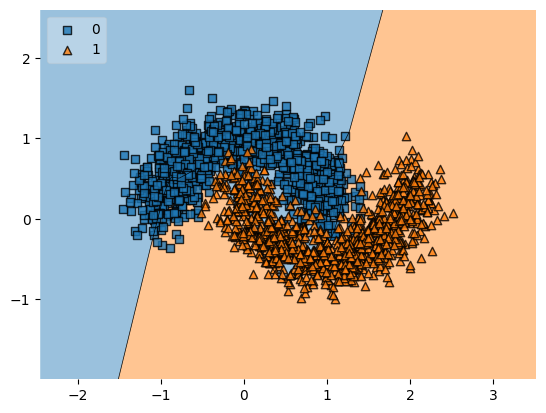

In [43]:
plot_decision_regions(X,y.astype('int'),clf=model,legend=2)

plt.show()

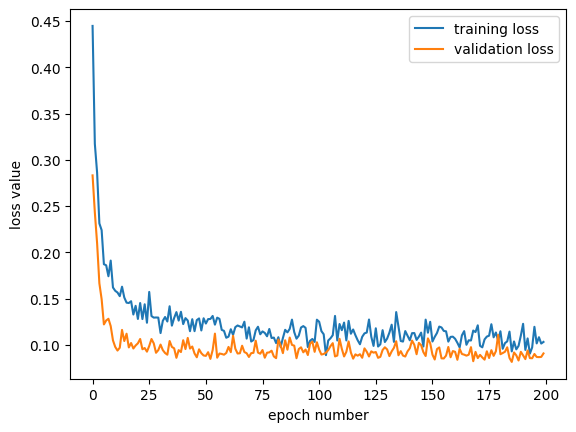

In [44]:
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel("epoch number")
plt.ylabel("loss value")
plt.legend()
plt.show()

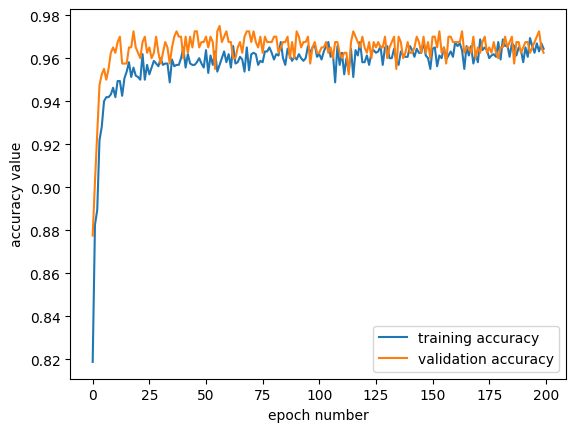

In [45]:
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel("epoch number")
plt.ylabel("accuracy value")
plt.legend()
plt.show()

In [46]:
loss,accuracy = model.evaluate(x_test,y_test,verbose=1)

print(f"{loss, accuracy}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9595 - loss: 0.1074 
(0.0906992182135582, 0.9624999761581421)


# Another model training using new data - mnist

In [47]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

print(x_train.shape,y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)


In [48]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [49]:
x_test[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  84, 185, 159, 151,  60,  36,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 222, 254, 254, 254, 254, 241, 198,
        198, 198, 198, 198, 198, 198, 198, 170,  52,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  67, 114,  72, 114, 163, 227, 254,
        225, 254, 254, 254, 250, 229, 254, 254, 140,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  17,  66,
         14,  67,  67,  67,  59,  21, 236, 254, 106,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,  83, 253, 209,  18,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  22, 233, 255,  83,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 129, 254, 238,  44,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,  59, 249, 254,  62,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0, 133, 254, 187,   5,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   9, 205, 248,  58,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 126, 254, 182,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  75, 251, 240,  57,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         19, 221, 254, 166,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
        203, 254, 219,  35,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  38,
        254, 254,  77,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  31, 224,
        254, 115,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 133, 254,
        254,  52,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [ ]:
y_train

In [ ]:
labels,counts = np.unique_counts(y_train)

label = len(labels)
label

In [ ]:
plt.imshow(x_train[0])

In [ ]:
x_train = x_train/255
x_test = x_test/255

x_train

In [ ]:
model = Sequential()
model.add(Flatten(input_shape=(x_train.shape[1],x_train.shape[2])))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(label,activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [ ]:
history = model.fit(x_train,y_train,epochs=10,validation_split=0.2,validation_data=(x_test,y_test),verbose=1)
history

In [ ]:
loss,accuracy = model.evaluate(x_test,y_test,verbose=1)

print(f"{loss, accuracy}")

In [ ]:
print(f"Accuracy: {accuracy*100:0.2f}% , Error: {100-accuracy*100:0.2f}%")

In [ ]:
pred = model.predict(x=x_test,verbose=1)

In [ ]:
y_pred = pred.argmax(axis=1)

In [ ]:
y_pred

In [ ]:
y_test

In [ ]:
plt.imshow(x_test[0])

In [ ]:
plt.imshow(x_train[0])

In [ ]:
images = x_train[0:10]
pred2 = model.predict(images)
sample_pred = pred2.argmax(axis=1)
sample_pred


In [ ]:
plt.imshow(x_train[1])

In [ ]:
model.save("multi_classification.keras")

In [ ]:
model2 = load_model("multi_classification.keras")

In [ ]:
images = x_train[0:10]
pred2 = model2.predict(images)
sample_pred = pred2.argmax(axis=1)
sample_pred

## binary classification nural network model

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
data = load_breast_cancer()

x = data.data
y = data.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)


In [ ]:
y[0:20]

In [ ]:
scaller = StandardScaler()
x_train = scaller.fit_transform(x_train)
x_test = scaller.transform(x_test)

In [ ]:
model = Sequential()
model.add(Dense(128,activation='relu',input_shape=(x_train.shape[1],)))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',metrics=['accuracy'],optimizer='Adam')

In [ ]:
model.summary()

In [ ]:
history = model.fit(x_train,y_train,epochs=20,validation_split=0.2,verbose=1)

In [ ]:
loss,accuracy = model.evaluate(x_test,y_test,verbose=0)
print(f"Accuracy: {accuracy*100:0.2f}% , Error: {100-accuracy*100:0.2f}%")